# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Running best Oracle model on all Image-Datasets [2] \
[7] Running best Oracle model on all Image-Datasets with a different backbone [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [1]:
# Some imports and general information

import mlflow
import numpy as np
import pandas as pd
import pylab as plt
from collections import defaultdict
import seaborn as sns
from IPython.display import display

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/perf_dal_2.db
# scp phahn@cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db .

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR10'}, 
    'stl10':{'qs':10, 'n':'STL10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'},
    'dopanim':{'qs':25, 'n':'Dopanim'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red', 'ls':'-'},
    'badge':{'n':'BADGE', 'c':'blue', 'ls':'-'},
    'bait':{'n':'BAIT', 'c':'green', 'ls':'-'},
    'coreset':{'n':'CoreSet', 'c':'purple', 'ls':'-'},
    'dropquery':{'n':'DropQuery', 'c':'orange', 'ls':'-'},
    'margin':{'n':'Margin', 'c':'cyan', 'ls':'-'},
    'random':{'n':'Random', 'c':'black', 'ls':'-'},
    'typiclust':{'n':'Typiclust', 'c':'pink', 'ls':'-'},

    'lazy+vary oracle(11)':{'n':'Lazy+Var Oracle (11)', 'c':'red', 'ls':'--'},
    'lazy+vary oracle(55)':{'n':'Lazy+Var Oracle (55)', 'c':'red', 'ls':':'},
    'lazy+vary oracle(110)':{'n':'Lazy+Var Oracle (110)', 'c':'red', 'ls':'-.'},

    'lazy oracle(11)':{'n':'Lazy Oracle (11)', 'c':'green', 'ls':'--'},
    'lazy oracle(55)':{'n':'Lazy Oracle (55)', 'c':'green', 'ls':':'},
    'lazy oracle(110)':{'n':'Lazy Oracle (110)', 'c':'green', 'ls':'-.'},

    'naive oracle(11)':{'n':'Naive Oracle (11)', 'c':'blue', 'ls':'--'},
    'naive oracle(55)':{'n':'Naive Oracle (55)', 'c':'blue', 'ls':':'},
    'naive oracle(110)':{'n':'Naive Oracle (110)', 'c':'blue', 'ls':'-.'},

    'Lazy+Vary Oracle (acq_size = 5)':{'n':'acq_size = 5', 'c':'orange', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 10)':{'n':'acq_size = 10', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 20)':{'n':'acq_size = 20', 'c':'green', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 40)':{'n':'acq_size = 40', 'c':'red', 'ls':'--'},

    'Lazy+Vary Oracle (perf_est = cross_entropy)':{'n':'perf_est = cross_entropy', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = zero_one)':{'n':'perf_est = zero_one', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = brier)':{'n':'perf_est = brier', 'c':'green', 'ls':'--'},

    'Lazy+Vary Oracle (train = train)':{'n':'train = train', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (train = update)':{'n':'train = update', 'c':'blue', 'ls':'--'},

    'lazy+vary+red oracle(11)':{'n':'Lazy+Var+Red Oracle (11)', 'c':'orange', 'ls':'--'},
    'lazy+vary+red oracle(55)':{'n':'Lazy+Var+Red Oracle (55)', 'c':'orange', 'ls':':'},
    'lazy+vary+red oracle(110)':{'n':'Lazy+Var+Red Oracle (110)', 'c':'orange', 'ls':'-.'},

    'lazy+vary+red oracle(5)':{'n':'Lazy+Var+Red Oracle (5)', 'c':'gray', 'ls':'--'},
    'lazy+vary+red oracle(25)':{'n':'Lazy+Var+Red Oracle (25)', 'c':'gray', 'ls':':'},
    'lazy+vary+red oracle(50)':{'n':'Lazy+Var+Red Oracle (50)', 'c':'gray', 'ls':'-.'},

    'lazy+vary+red(1) oracle(110)':{'n':'Lazy+Var+Red(1) Oracle (110)', 'c':'silver', 'ls':'-.'},
    'lazy+vary+red(2) oracle(110)':{'n':'Lazy+Var+Red(2) Oracle (110)', 'c':'red', 'ls':'-.'},
    'lazy+vary+red(3) oracle(110)':{'n':'Lazy+Var+Red(3) Oracle (110)', 'c':'green', 'ls':'-.'},
    'lazy+vary+red(4) oracle(110)':{'n':'Lazy+Var+Red(4) Oracle (110)', 'c':'blue', 'ls':'-.'},
    'lazy+vary+red(5) oracle(110)':{'n':'Lazy+Var+Red(5) Oracle (110)', 'c':'gray', 'ls':'-.'},
    'lazy+vary+red(6) oracle(110)':{'n':'Lazy+Var+Red(6) Oracle (110)', 'c':'yellow', 'ls':'-.'},
    'lazy+vary+red(7) oracle(110)':{'n':'Lazy+Var+Red(7) Oracle (110)', 'c':'purple', 'ls':'-.'},
    'lazy+vary+red(8) oracle(110)':{'n':'Lazy+Var+Red(8) Oracle (110)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary+red(9) oracle(110)':{'n':'Lazy+Var+Red(9) Oracle (110)', 'c':'pink', 'ls':'-.'},
    'lazy+vary+red(10) oracle(110)':{'n':'Lazy+Var+Red(10) Oracle (110)', 'c':'brown', 'ls':'-.'},
    'lazy+vary+red(11) oracle(110)':{'n':'Lazy+Var+Red(11) Oracle (110)', 'c':'black', 'ls':'-.'},


    'lazy+vary oracle(110) cross_entropy 0.01':{'n':'Cross Entropy (0.01)', 'c':'yellow', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 0.01':{'n':'Zero One (0.01)', 'c':'yellow', 'ls':'-'},
    'lazy+vary oracle(110) brier 0.01':{'n':'Brier (0.01)', 'c':'yellow', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 0.1':{'n':'Cross Entropy (0.1)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 0.1':{'n':'Zero One (0.1)', 'c':'cyan', 'ls':'-'},
    'lazy+vary oracle(110) brier 0.1':{'n':'Brier (0.1)', 'c':'cyan', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 1':{'n':'Cross Entropy (1)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 1':{'n':'Zero One (1)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) brier 1':{'n':'Brier (1)', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 2':{'n':'Cross Entropy (2)', 'c':'purple', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 2':{'n':'Zero One (2)', 'c':'purple', 'ls':'-'},
    'lazy+vary oracle(110) brier 2':{'n':'Brier (2)', 'c':'purple', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 5':{'n':'Cross Entropy (5)', 'c':'brown', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 5':{'n':'Zero One (5)', 'c':'brown', 'ls':'-'},
    'lazy+vary oracle(110) brier 5':{'n':'Brier (5)', 'c':'brown', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 10':{'n':'Cross Entropy (10)', 'c':'green', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 10':{'n':'Zero One (10)', 'c':'green', 'ls':'-'},
    'lazy+vary oracle(110) brier 10':{'n':'Brier (10)', 'c':'green', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 20':{'n':'Cross Entropy (20)', 'c':'blue', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 20':{'n':'Zero One (20)', 'c':'blue', 'ls':'-'},
    'lazy+vary oracle(110) brier 20':{'n':'Brier (20)', 'c':'blue', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 25':{'n':'Cross Entropy (25)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 25':{'n':'Zero One (25)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) brier 25':{'n':'Brier (25)', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 30':{'n':'Cross Entropy (30)', 'c':'orange', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 30':{'n':'Zero One (30)', 'c':'orange', 'ls':'-'},
    'lazy+vary oracle(110) brier 30':{'n':'Brier (30)', 'c':'orange', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 50':{'n':'Cross Entropy (50)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 50':{'n':'Zero One (50)', 'c':'cyan', 'ls':'-'},
    'lazy+vary oracle(110) brier 50':{'n':'Brier (50)', 'c':'cyan', 'ls':'--'},

    'Oracle':{'n':'Oracle', 'c':'black', 'ls':'-.'},

    "True - ['random', 'dropquery']":{'n':'DropQuery', 'c':'orange', 'ls':'-'}, 
    "False - ['random', 'dropquery']":{'n':'DropQuery', 'c':'orange', 'ls':'--'},
    "True - ['random', 'coreset']":{'n':'CoreSet', 'c':'purple', 'ls':'-'}, 
    "False - ['random', 'coreset']":{'n':'CoreSet', 'c':'purple', 'ls':'--'}, 
    "True - ['random', 'badge']":{'n':'BADGE', 'c':'blue', 'ls':'-'}, 
    "False - ['random', 'badge']":{'n':'BADGE', 'c':'blue', 'ls':'--'}, 
    "True - ['random', 'bait']":{'n':'BAIT', 'c':'green', 'ls':'-'}, 
    "False - ['random', 'bait']":{'n':'BAIT', 'c':'green', 'ls':'--'}, 
    "True - ['random', 'alfamix']":{'n':'AlfaMix', 'c':'red', 'ls':'-'}, 
    "False - ['random', 'alfamix']":{'n':'AlfaMix', 'c':'red', 'ls':'--'}, 
    "True - ['random', 'typiclust']":{'n':'Typiclust', 'c':'pink', 'ls':'-'}, 
    "False - ['random', 'typiclust']":{'n':'Typiclust', 'c':'pink', 'ls':'--'}, 
    "True - ['random', 'loss']":{'n':'TypiClass', 'c':'brown', 'ls':'-'},
    "False - ['random', 'loss']":{'n':'TypiClass', 'c':'brown', 'ls':'--'},
    "True - ['random', 'margin']":{'n':'Margin', 'c':'cyan', 'ls':'-'}, 
    "False - ['random', 'margin']":{'n':'Margin', 'c':'cyan', 'ls':'--'}, 
    "True - ['random', 'dropqueryclass']":{'n':'DropQueryClass', 'c':'yellow', 'ls':'-'},
    "False - ['random', 'dropqueryclass']":{'n':'DropQueryClass', 'c':'yellow', 'ls':'--'}
}

sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']
sampling_strategies_red =  ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'coreset', 'typiclass', 'losssampling', 'dropqueryclass']

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal_2.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

def style_negative(v, props=''):
    return props if v.count('-') > 1 else None

def df_style(val):
    return "font-weight: bold"

In [13]:
# Plotting functions for a pairwise comparison in one dset, averaged over all dsets and a global comparison

def plot_global_pairwise_comparison(results, dsets, strategies):
    # Compute win rates
    win_rates = pd.DataFrame(index=strategies, columns=strategies)
    for strat1 in strategies:
        for strat2 in strategies:
            if strat1 == strat2:
                win_rates.loc[strat1, strat2] = 0.0
            else:
                accs1, accs2 = [], []
                for dset in dsets:
                    accs1.extend(results[dset][strat1])
                    accs2.extend(results[dset][strat2])
                means1 = np.mean(accs1, axis=1)
                means2 = np.mean(accs2, axis=1)
                comparisons = means1.round(4) > means2.round(4)
                wins = np.sum(comparisons) / min(means1.shape[0], means2.shape[0])
                win_rates.loc[strat1, strat2] = wins
    win_rates.index = [strat.capitalize() for strat in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    win_rates *= 100
    win_rates = win_rates.sort_index(axis=0)
    win_rates = win_rates.sort_index(axis=1)
    plt.figure(figsize=(6, 5))
    sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=50)
    plt.title(f"Global Pairwise Comparison")
    plt.ylabel("Challenged Strategy")
    plt.xlabel("Challenging Strategy")
    plt.tight_layout()
    plt.show() 

def plot_pairwise_comparison(results, dsets, strategies):
    # Compute win rates
    for dset in dsets:
        win_rates = pd.DataFrame(index=strategies, columns=strategies)
        for strat1 in strategies:
            for strat2 in strategies:
                if strat1 == strat2:
                    win_rates.loc[strat1, strat2] = 0.0
                else:
                    means1 = np.mean(results[dset][strat1], axis=1)
                    means2 = np.mean(results[dset][strat2], axis=1)
                    comparisons = means1.round(4) > means2.round(4)
                    wins = np.sum(comparisons) / min(means1.shape[0], means2.shape[0])
                    win_rates.loc[strat1, strat2] = wins
        win_rates.index = [strat.capitalize() for strat in win_rates.index]
        win_rates.columns = [strat.capitalize() for strat in win_rates.columns]
        # Plot the heatmap
        win_rates *= 100
        win_rates = win_rates.sort_index(axis=0)
        win_rates = win_rates.sort_index(axis=1)
        plt.figure(figsize=(6, 5))
        sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=50)
        plt.title(f"{dset.capitalize()}")
        plt.ylabel("Challenged Strategy")
        plt.xlabel("Challenging Strategy")
        plt.tight_layout()
        plt.show()

def plot_global_comparison(results, dsets, strategies):
    # Compute win rates
    win_rates = pd.DataFrame(index=dsets, columns=strategies)
    for dset in dsets:
        for strat1 in strategies:
            means1 = np.mean(results[dset][strat1], axis=1)
            comparisons = []
            for strat2 in strategies:
                if strat2 != strat1:
                    means2 = np.mean(results[dset][strat2], axis=1)
                    comparison = means1.round(4) > means2.round(4)
                    comparisons.append(comparison)
            comp = np.prod(comparisons, axis=0)
            wins = np.sum(comp) / means1.shape[0]
            win_rates.loc[dset, strat1] = wins

    win_rates.index = [dset.capitalize() for dset in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    win_rates *= 100
    win_rates = win_rates.sort_index(axis=0)
    win_rates = win_rates.sort_index(axis=1)

    plt.figure(figsize=(6, 5))
    plt.title(f"Highest AUC per Dataset (%)")
    sns.heatmap(win_rates.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=50)
    plt.ylabel("Dataset")
    plt.xlabel("Strategy")
    plt.tight_layout()
    plt.show()


def plot_average_pick_choices(all_pick_choices, fig_strats, fig_dsets, sampling_strategies, figsize=(14, 5), cmap = 'viridis'):
    n_plots = len(fig_dsets) * len(fig_strats)

    fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=figsize, width_ratios=[1 for _ in range(n_plots)]+ [.2])
    fig.suptitle("Average Oracle Pick-Choices")

    for a, dset in enumerate(fig_dsets):
        n_queries = 20
        for b, strat in enumerate(fig_strats):
            j = a * len(fig_strats) + b            
            image = []
            vmin, vmax = 1, 0
            for sampl_strat in sampling_strategies:
                img = []
                for seed in range(10):
                    im = []
                    if seed < len(all_pick_choices[dset][strat]):
                        for i in range(n_queries):
                            if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                                if i == 0:
                                    im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                                else:
                                    im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                            else:
                                im.append(0)
                        img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

            c1 = ax[j].imshow(img_avg, cmap=cmap)
            ax[j].set_xticks(ticks=[0], labels=[strat])
            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(dset)

            j += 1

    fig.colorbar(c1, cax=ax[-1])
    plt.show()

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [14]:
experiment_name = 'experiment_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name,10 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params:
        key = run.data.params['al.strategy']
        dataset = run.data.params['dataset_name']
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

        if len(accs) == 21:
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = defaultdict(list)
            all_acc_curves_strategies[dataset][key].append(accs)
            if dataset not in query_times:
                query_times[dataset] = defaultdict(list)
            query_times[dataset][key].append(qts)
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_1 #####################################
Found 725 experiments for experiment_1 with expected 800 experiments.
Issue with coreset dopanim Seed_10


In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(16, 9), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust']

for i, dset in enumerate(datasets):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i%2][i//2])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if qs in strategies:
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

#plot_global_pairwise_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)
#plot_global_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)

## Experiment 2 - Oracle Baselines

The second experiment investigates different variants of the oracle strategy and additionally tests them for different number of batches per cycle to investigate.

Oracle_Variants = [Naive, Lazy, Intelligent but Lazy]

Batch_Sizes = [11, 55, 110]

In [9]:
experiment_name = 'experiment_2'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3 * 3)) # n_dsets * n_seeds * n_oracles * n_batches

for run in runs_strategies:
    key = ('lazy' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + ('+vary ' if run.data.params['al.optimal.vary_strat_subset_size'] == 'True' else ' ') + 'oracle' + '('+ run.data.params['al.optimal.num_batches'] +')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_2 #####################################
Found 180 experiments for experiment_2 with expected 180 experiments.


In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if ('oracle' in qs and ('naive' in qs or 'lazy+vary' in qs or 'lazy' in qs)) or qs == 'random':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.225, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

In [ ]:
cmap = 'viridis'
fig_strats = ['lazy oracle(11)', 'lazy+vary oracle(11)', 'lazy oracle(55)', 'lazy+vary oracle(55)', 'lazy oracle(110)', 'lazy+vary oracle(110)']
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(14, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle defined by Subsettype (NumBatches)")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[("Vary" if "vary" in strat else "Static") + " ("+strat.split('(')[1][:-1]+")"])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

In [ ]:
cmap = 'viridis'
for dset in ['cifar10', 'dtd']:
    for strat in ['lazy oracle(11)', 'lazy+vary oracle(11)', 'lazy oracle(55)', 'lazy+vary oracle(55)', 'lazy oracle(110)', 'lazy+vary oracle(110)']:
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8, 4), width_ratios=[19., 1., .75])
        fig.suptitle(f"Average Batch-Choice for {strat} on {dset}")

        query_size = datasets[dset]['qs']
        n_queries = 20

        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img_avg = np.mean(image, axis=1)[:,1:]
        img_avg_avg = np.mean(img_avg, axis=-1)

        c1 = ax[0].imshow(img_avg)
        ax[0].set_xticks(ticks=range(0,19), labels=range(1, 20))
        ax[0].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)

        ax[1].imshow(img_avg_avg.reshape(-1, 1))
        ax[1].set_xticks(ticks=[0], labels=["Avg."])
        ax[1].set_yticks(ticks=[], labels=[])

        fig.colorbar(c1, cax=ax[-1])
        plt.show()

## Experiment 3 - How does the query size impact the oracle?

This experiment demonstrates the change in performance when increasing the acq_size while keeping the total number of acquisitions over the experiment constant. 

We only use the strategy lazy+vary oracle(110) as it is the strongest performer.

Num_Acqs = [10, 20, 40]

Datasets = [CIFAR10, STL10]

In [ ]:
experiment_name = 'experiment_3'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 3 * 10 * 4)) # n_dsets * n_seeds * n_acq_sizes

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (acq_size = '+run.data.params['al.acq_size']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(2)) + '+/-' + str(rand_auc_std.round(2))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if 'acq_size' in qs or qs == 'random':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(2)) + '+/-' + str(aucs_std.round(2))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

## Experiment 4 - How does the performance estimation impact the oracle?

In this experiment, we investigate the influence of the performance metric used for evaluating the different batches.

Perf_Est = [Cross Entropy, 0/1 Loss, Brier Score]

In [ ]:
experiment_name = 'experiment_4'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_loss_fn

for run in runs_strategies:
    key = f'Lazy+Vary Oracle (perf_est = '+run.data.params['al.optimal.loss']+')'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if ('perf' in qs) or qs == 'random':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.225, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

In [ ]:
cmap = 'viridis'
fig_strats = ['Lazy+Vary Oracle (perf_est = cross_entropy)', 'Lazy+Vary Oracle (perf_est = zero_one)', 'Lazy+Vary Oracle (perf_est = brier)']
fig_dsets = ['cifar10', 'dtd']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(12, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Lazy+Var Oracle(110) with different performance estimations")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[strat.split('=')[1][:-1]])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

## Experiment 5 - How does the retraining process impact the oracle?

This experiment investigates wether using bayesian updates instead of retraining the model from scratch can serve as a good performance estimator, making the oracle more efficient.

In [ ]:
experiment_name = 'experiment_5'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 10 * 3)) # n_dsets * n_seeds * n_gammas * n_loss_fn

for run in runs_strategies:
    loss_fn = run.data.params['al.optimal.loss']
    update_gamma = run.data.params['al.optimal.update_gamma']

    key = f'lazy+vary oracle(110) ' + loss_fn + ' ' + update_gamma
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['lazy+vary oracle(110)'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['lazy+vary oracle(110)'] = str(rand_auc_mean.round(2)) + '+/-' + str(rand_auc_std.round(2))
    final_acc_rel[dset]['lazy+vary oracle(110)'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if 'zero_one ' in qs or qs == 'lazy+vary oracle(110)':
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'lazy+vary oracle(110)':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(2)) + '+/-' + str(aucs_std.round(2))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.25, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == 'lazy+vary oracle(110)'], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == 'lazy+vary oracle(110)'], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

In [ ]:
qts = {}

for dset in ['cifar10', 'dtd']:
    qts[dset] = {}
    for strat in ['lazy+vary oracle(110)', 'lazy+vary oracle(110) zero_one 10']:
        qts[dset][strat] = {}
        times = np.mean(query_times[dset][strat], axis=0).round(2)
        for cycle in range(20):
            qts[dset][strat]['Cycle '+str(cycle)] = times[cycle]

flat_dict = {}
for group, subdict in qts.items():
    for sub, rows in subdict.items():
        for row, value in rows.items():
            flat_dict.setdefault(row, {})[(group, sub)] = value

# Step 2: Create the DataFrame
df = pd.DataFrame.from_dict(flat_dict, orient='index')

# Step 3: Sort columns if needed
df = df.sort_index(axis=1)

df

# Experiment 6 - Final Oracle Model on all Image-Datasets

The final oracle-model is build as follows:

Number of Batches: 110

Selection Strategies: All except Margin and BADGE

Performance Estimation: Brier-Score

In [ ]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle'
    dataset = run.data.params['dataset_name']
    backbone = run.data.params['backbone']
    if backbone == 'dinov2':
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']:
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = defaultdict(list)
            all_acc_curves_strategies[dataset][key].append(accs)
            if dataset not in query_times:
                query_times[dataset] = defaultdict(list)
            query_times[dataset][key].append(qts)
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = defaultdict(list)
            all_pick_choices[dataset][key].append(pick_choices)
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'typiclust', 'coreset', 'Oracle']

for i, dset in enumerate(datasets):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if qs in strategies:
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies[:-1])
plot_average_pick_choices(all_pick_choices=all_pick_choices, fig_strats=['Oracle'], fig_dsets=all_pick_choices.keys(), sampling_strategies=sampling_strategies_red)

## Experiment 7: Baselines+Oracle with a new Backbone (SwinV2) on all Image Datasets
Accidentally, i also saved this final oracle under the same experiment number (experiment_7). I therefore need to make a case differentiation between the backbones for future evaluations for both backbones!!!

In [ ]:
all_acc_curves_strategies_2 = {}
all_pick_choices_2 = {}
query_times_2 = {}

In [ ]:
experiment_name = 'experiment_8'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies_2:
            all_acc_curves_strategies_2[dataset] = defaultdict(list)
        all_acc_curves_strategies_2[dataset][key].append(accs)
        if dataset not in query_times_2:
            query_times_2[dataset] = defaultdict(list)
        query_times_2[dataset][key].append(qts)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle'
    dataset = run.data.params['dataset_name']
    backbone = run.data.params['backbone']
    if backbone == 'swinv2':
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']:
            if dataset not in all_acc_curves_strategies_2:
                all_acc_curves_strategies_2[dataset] = defaultdict(list)
            all_acc_curves_strategies_2[dataset][key].append(accs)
            if dataset not in query_times_2:
                query_times_2[dataset] = defaultdict(list)
            query_times_2[dataset][key].append(qts)
            if dataset not in all_pick_choices_2:
                all_pick_choices_2[dataset] = defaultdict(list)
            all_pick_choices_2[dataset][key].append(pick_choices)
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'typiclust', 'coreset', 'Oracle']

for i, dset in enumerate(datasets):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies_2[dset]['random'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies_2[dset]:
        if qs in strategies:
            accs = all_acc_curves_strategies_2[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'random':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies_2, all_acc_curves_strategies_2.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies_2, all_acc_curves_strategies_2.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies_2, all_acc_curves_strategies_2.keys(), strategies[:-1])
plot_average_pick_choices(all_pick_choices=all_pick_choices_2, fig_strats=['Oracle'], fig_dsets=all_pick_choices_2.keys(), sampling_strategies=sampling_strategies_red)

# Additional Ablations

## Sequential Selection Strategy Reduction

These experiments aim to investigate how our model behaves if we sequentially reduce its pick choices by the least picked Choice

In [ ]:
cmap = 'viridis'
fig_strats = ['lazy+vary oracle(110)']
fig_dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle defined by Subsettype (NumBatches)")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[("Vary" if "vary" in strat else "Static") + " ("+strat.split('(')[1][:-1]+")"])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

### Removing BADGE from selection strategies

In [18]:
experiment_name = 'experiment_9_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle (-0)'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_9_1 #####################################
Found 20 experiments for experiment_9_1 with expected 20 experiments.


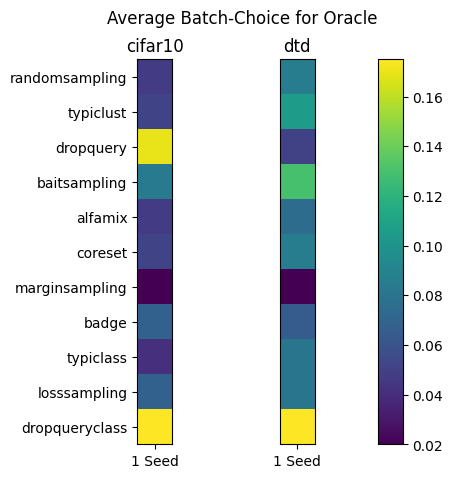

In [19]:
cmap = 'viridis'
fig_strats = ['Oracle (-0)']
fig_dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'coreset', 'marginsampling', 'badge', 'typiclass', 'losssampling', 'dropqueryclass']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat]) > 0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=['10 Seeds' if 'vary' in strat else '1 Seed'])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()